# Portfolio Drift Monitor - Evaluation and Risk

**Stage 11.** Stage 10a fitted a model and then refused to quote a single interval from
it, because a 21-day forward target leaves about 24 independent observations and every
standard error assumed 501. This notebook says what can honestly be said about
uncertainty, and where the honest answer is "not this, from this much data".

Reasoning in `docs/evaluation.md`. Three things come out of it that change what the
monitor may publish:

1. the prediction interval is **11 times** wider than the confidence interval, and the
   prediction interval is the one Dana needs;
2. the pooled model is **systematically biased** for VTI and BND, by 0.21pp and 0.13pp;
3. the test window is too short to bound its own uncertainty at the timescale that
   matters, so every interval here is a floor.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import features as fe
from src import modeling as md
from src import evaluation as ev
from src.utils import TARGET_WEIGHTS, AMBER_PP, RED_PP, read_df

sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

SEED, N_BOOT, LEVEL = 111, 2000, 0.95
np.random.seed(SEED)

RAW, PROC = Path('data/raw'), Path('data/processed')
IMG = Path('reports/images'); IMG.mkdir(parents=True, exist_ok=True)
HORIZON = 21
TARGET = f'y_absdrift_fwd_{HORIZON}'
TICKERS = list(TARGET_WEIGHTS)

print('seed %d | %d resamples | level %.2f | amber %.1fpp' % (SEED, N_BOOT, LEVEL, AMBER_PP))

seed 111 | 2000 resamples | level 0.95 | amber 3.0pp


## 1. The model under evaluation

The Stage 10a regression, refitted on the same chronological split. Nothing new is
modelled. The subject here is the uncertainty around numbers that already exist.

In [3]:
clean = sorted(PROC.glob('prices_clean_*.parquet'))
src_path = clean[-1] if clean else sorted(RAW.glob('api_yfinance_*.csv'))[-1]
prices = read_df(src_path) if str(src_path).endswith('parquet') else pd.read_csv(src_path)
prices['date'] = pd.to_datetime(prices['date'])

matrix = fe.build_feature_matrix(prices, TARGET_WEIGHTS, prices_raw=prices, horizon=HORIZON)
matrix = fe.make_forward_target(matrix, horizon=HORIZON, col='drift_rel',
                                absolute=True, out_col='y_rel')

FULL = [c for c in fe.MODEL_FEATURES if c != 'ticker_BND']
FIVE = ['abs_drift', 'abs_drift_rel', 'drift_chg_1', 'drift_chg_5', 'drift_slope_21']

data = (matrix[['date', 'ticker'] + fe.MODEL_FEATURES + [TARGET, 'y_rel']]
        .dropna().sort_values(['date', 'ticker']).reset_index(drop=True))
train, test, cut = md.chronological_split(data, test_frac=0.2)

fit = md.fit_ols(train[FULL].to_numpy(), train[TARGET].to_numpy(), FULL)
pred = md.predict_ols(fit['beta'], test[FULL].to_numpy())
resid = test[TARGET].to_numpy() - pred

print('source: %s' % src_path.name)
print('cut %s | train %d rows | test %d rows over %d dates'
      % (cut.date(), len(train), len(test), test['date'].nunique()))
print('MAE %.4f pp | RMSE %.4f pp | bias %+.4f pp' % (ev.mae(resid), ev.rmse(resid), ev.bias(resid)))

source: prices_clean_20260829-1733.parquet
cut 2026-06-01 | train 501 rows | test 126 rows over 42 dates
MAE 0.1915 pp | RMSE 0.2333 pp | bias +0.0951 pp


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta
/Users/an

## 2. How wide is the honest interval?

Two bootstraps. The ordinary one draws rows independently, which assumes they are
independent; on this panel they are not. The moving block bootstrap draws contiguous date
blocks, so dependence survives the resampling.

The block length has to be at least as long as the dependence, which for a 21-day target
means 21 days. The sweep shows why that is not achievable here.

In [4]:
iid = ev.iid_bootstrap(resid, ev.mae, n_boot=N_BOOT, seed=SEED, level=LEVEL)
blk = ev.block_bootstrap(test, resid, ev.mae, block=HORIZON, n_boot=N_BOOT,
                         seed=SEED, level=LEVEL)
sweep = ev.block_length_sweep(test, resid, ev.mae, blocks=(1, 3, 5, 10, 21, 42),
                              n_boot=N_BOOT, seed=SEED, level=LEVEL)

print('MAE %.4f pp' % iid['point'])
print('  iid   95%% CI [%.4f, %.4f] width %.4f' % (iid['lo'], iid['hi'], iid['width']))
print('  block 95%% CI [%.4f, %.4f] width %.4f  (%d blocks from %d start positions)'
      % (blk['lo'], blk['hi'], blk['width'], blk['blocks_per_draw'], blk['n_distinct_starts']))
print()
print(sweep.to_string())

MAE 0.1915 pp
  iid   95% CI [0.1696, 0.2161] width 0.0465
  block 95% CI [0.1849, 0.2173] width 0.0324  (2 blocks from 22 start positions)

            blocks_per_draw  n_distinct_starts      lo      hi   width
block_days                                                            
1                        42                 42  0.1694  0.2136  0.0442
3                        14                 40  0.1608  0.2242  0.0634
5                         9                 38  0.1630  0.2271  0.0641
10                        5                 33  0.1804  0.2245  0.0441
21                        2                 22  0.1849  0.2173  0.0324
42                        1                  1  0.1915  0.1915  0.0000


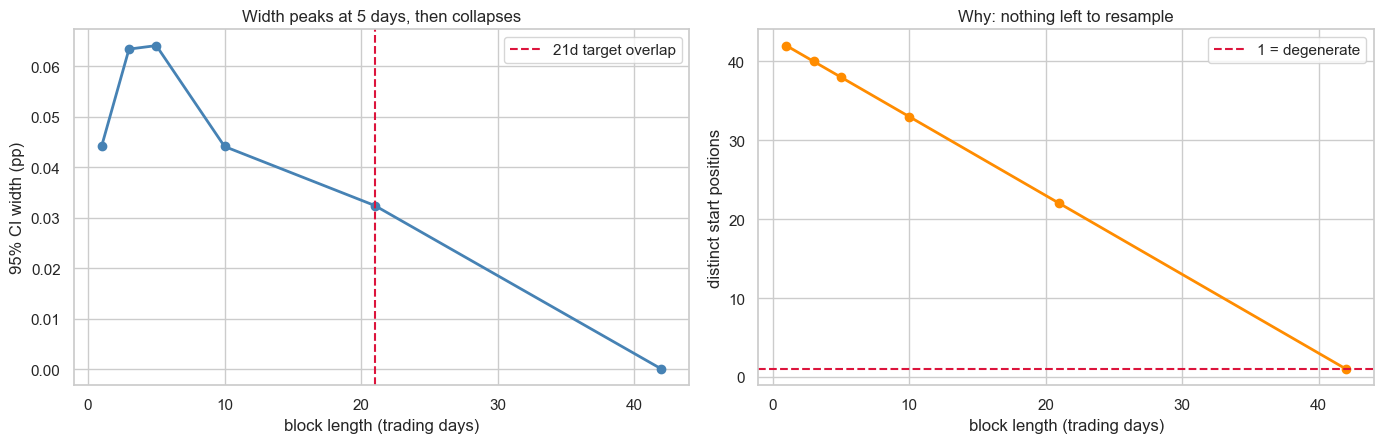

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].plot(sweep.index, sweep['width'], 'o-', linewidth=2, color='steelblue')
axes[0].axvline(HORIZON, color='crimson', linestyle='--', label=f'{HORIZON}d target overlap')
axes[0].set_xlabel('block length (trading days)'); axes[0].set_ylabel('95% CI width (pp)')
axes[0].set_title('Width peaks at 5 days, then collapses'); axes[0].legend()

axes[1].plot(sweep.index, sweep['n_distinct_starts'], 'o-', linewidth=2, color='darkorange')
axes[1].axhline(1, color='crimson', linestyle='--', label='1 = degenerate')
axes[1].set_xlabel('block length (trading days)'); axes[1].set_ylabel('distinct start positions')
axes[1].set_title('Why: nothing left to resample'); axes[1].legend()

fig.tight_layout()
fig.savefig(IMG / 'eval_block_bootstrap.png', dpi=110, bbox_inches='tight')
plt.show()

**Acknowledging dependence widens the honest interval by about 45%**, from 0.044 at block
1 to 0.064 at block 5. Past that the width *falls*, to 0.032 at block 21 and to exactly
zero at block 42, where only one sample is possible.

That fall is an artifact. With 42 test dates a 21-day block has 22 possible starting
positions, so replicates overlap almost completely and the interval is narrow for the
wrong reason.

**The block length this target requires is inside the region where the estimator has
already degenerated.** So the honest output is a constraint rather than a number: the best
available interval is **MAE 0.19pp, 95% CI [0.163, 0.227]** from short blocks, and it
should be read as a floor on the true uncertainty.

## 3. Which interval should the monitor publish?

Two questions that are easy to conflate. A **confidence** interval asks where the true
average relationship sits. A **prediction** interval asks where one new observation will
land. Dana reads one fund on one day.

In [6]:
comparison = ev.interval_comparison(resid, levels=(0.80, 0.95, 0.99))
g = ev.gaussian_intervals(resid, LEVEL)
e = ev.empirical_intervals(resid, LEVEL)

display(comparison)
print('confidence interval (the relationship) +/- %.4f pp' % g['ci_half_width'])
print('prediction interval (one fund-day)     +/- %.4f pp' % g['pi_half_width'])
print('ratio %.1fx' % g['pi_over_ci'])
print('residual skew %+.3f | excess kurtosis %+.3f' % (e['skew'], e['excess_kurtosis']))

,gaussian_pi,empirical_pi,ratio,gaussian_ci
level,,,,
0.80,0.2742,0.2761,1.0072,0.0244
0.95,0.4193,0.3835,0.9146,0.0374
0.99,0.5510,0.5102,0.9260,0.0491


confidence interval (the relationship) +/- 0.0374 pp
prediction interval (one fund-day)     +/- 0.4193 pp
ratio 11.2x
residual skew -0.242 | excess kurtosis -0.182


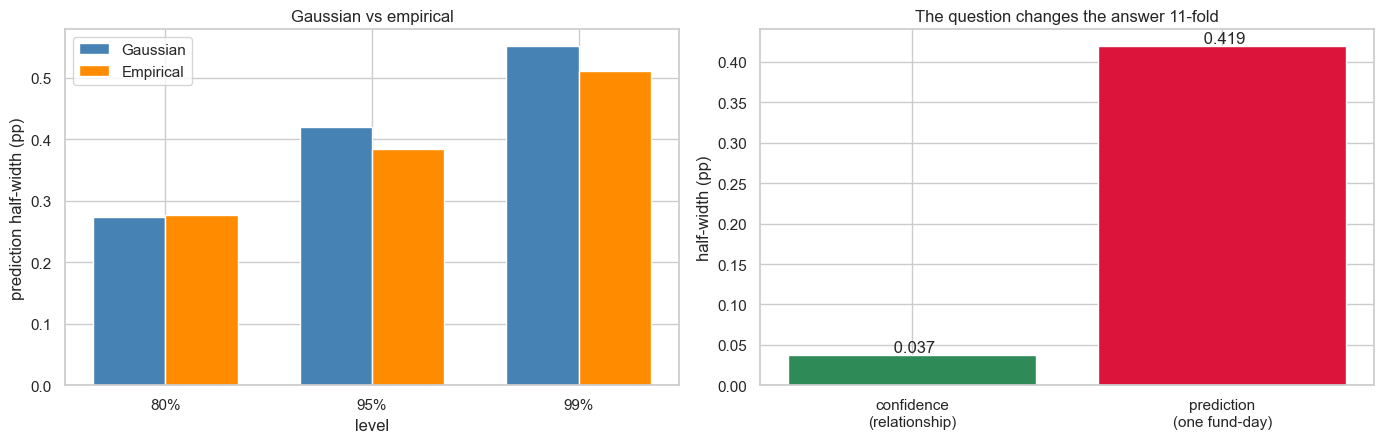

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
x = np.arange(len(comparison)); w = 0.35
axes[0].bar(x - w/2, comparison['gaussian_pi'], w, label='Gaussian', color='steelblue')
axes[0].bar(x + w/2, comparison['empirical_pi'], w, label='Empirical', color='darkorange')
axes[0].set_xticks(x); axes[0].set_xticklabels([f'{v:.0%}' for v in comparison.index])
axes[0].set_xlabel('level'); axes[0].set_ylabel('prediction half-width (pp)')
axes[0].set_title('Gaussian vs empirical'); axes[0].legend()

axes[1].bar(['confidence\n(relationship)', 'prediction\n(one fund-day)'],
            [g['ci_half_width'], g['pi_half_width']], color=['seagreen', 'crimson'])
axes[1].set_ylabel('half-width (pp)')
axes[1].set_title('The question changes the answer %.0f-fold' % g['pi_over_ci'])
for i, v in enumerate([g['ci_half_width'], g['pi_half_width']]):
    axes[1].text(i, v, f' {v:.3f}', ha='center', va='bottom')

fig.tight_layout()
fig.savefig(IMG / 'eval_intervals.png', dpi=110, bbox_inches='tight')
plt.show()

**The normality assumption is mildly conservative here, which is the opposite of the
usual worry.** The empirical band is 1.01x the Gaussian at 80%, 0.91x at 95% and 0.93x at
99%. Excess kurtosis is **-0.18**, so tails slightly thinner than normal, not fatter. That
had to be measured rather than assumed, and it is the safer direction to be wrong in.

**The far larger effect is the question.** Confidence 0.037pp against prediction 0.419pp,
a factor of **11**. Publishing the confidence interval to someone reading one fund on one
day would understate the uncertainty by an order of magnitude.

## 4. Scenario sensitivity: does the unit change the conclusion?

Stage 07 left the pp-versus-relative threshold unit open with the principal, and Stage 09
found the relative form more predictable. The question that matters for that decision is
narrower: **does the model's value depend on which unit is chosen?**

/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta
/Users/an

,model_mae,persistence_mae,beats_persistence_pct
pp / 11 features,0.1915,0.2372,19.2357
pp / 5 features,0.1759,0.2372,25.8208
relative / 11 features,0.9610,1.0548,8.8938
relative / 5 features,0.7850,1.0548,25.5787


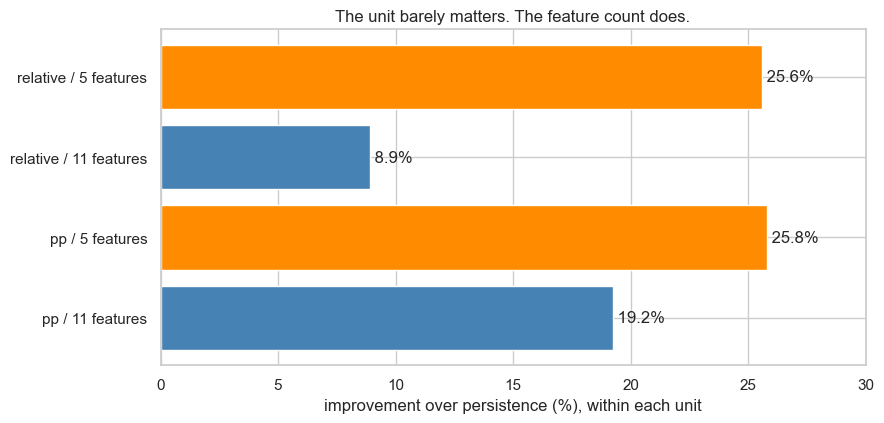

In [8]:
rows = {}
for unit_name, target_col, naive_col in [('pp', TARGET, 'abs_drift'),
                                         ('relative', 'y_rel', 'abs_drift_rel')]:
    for feat_name, feats in [('11 features', FULL), ('5 features', FIVE)]:
        f = md.fit_ols(train[feats].to_numpy(), train[target_col].to_numpy(), feats)
        r = test[target_col].to_numpy() - md.predict_ols(f['beta'], test[feats].to_numpy())
        rn = test[target_col].to_numpy() - test[naive_col].to_numpy()
        rows[f'{unit_name} / {feat_name}'] = {
            'model_mae': ev.mae(r), 'persistence_mae': ev.mae(rn),
            'beats_persistence_pct': 100 * (1 - ev.mae(r) / ev.mae(rn))}
units = ev.scenario_table(rows).round(4)
display(units)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(units.index, units['beats_persistence_pct'],
        color=['steelblue' if '11' in i else 'darkorange' for i in units.index])
ax.set_xlabel('improvement over persistence (%), within each unit')
ax.set_xlim(0, 30)
ax.set_title('The unit barely matters. The feature count does.')
for i, v in enumerate(units['beats_persistence_pct']):
    ax.text(v, i, f' {v:.1f}%', va='center')
fig.tight_layout()
fig.savefig(IMG / 'eval_unit_scenarios.png', dpi=110, bbox_inches='tight')
plt.show()

**With five features the model beats persistence by 25.8% in percentage points and 25.6%
in relative units.** The same number.

So the conclusion is robust to the unit, and **the principal can settle that question on
operational grounds rather than modelling grounds**. That is a useful thing to be able to
tell them after three stages of the question sitting open.

What is not robust is the feature count: eleven features beat persistence by only 8.9% in
the relative unit against 25.6% for five. Stage 10a's overfitting is worse in relative
units, so if the unit does change, the smaller model matters more.

## 5. Subgroup diagnostic: is the pooled model fair to each fund?

Stage 08 found `vol_21` correlates **+0.57 for BND and -0.23 for VTI**, so one pooled
coefficient is wrong for both in opposite directions. If that damage is real it shows up
as per-fund bias.

MAE and bias are separated deliberately: a large MAE with zero bias is noise, which more
data fixes; a large MAE that is mostly bias is a fixed error, which it does not.

,n,mae,mae_lo,mae_hi,bias,bias_lo,bias_hi,bias_excludes_zero,bias_share_of_mae
ticker,,,,,,,,,
BND,42,0.1691,0.0955,0.2321,0.1340,0.0514,0.2228,True,0.7923
VTI,42,0.2459,0.2138,0.3369,0.2147,0.1691,0.3365,True,0.8735
VXUS,42,0.1597,0.0984,0.2294,-0.0634,-0.2080,0.0267,False,0.3971


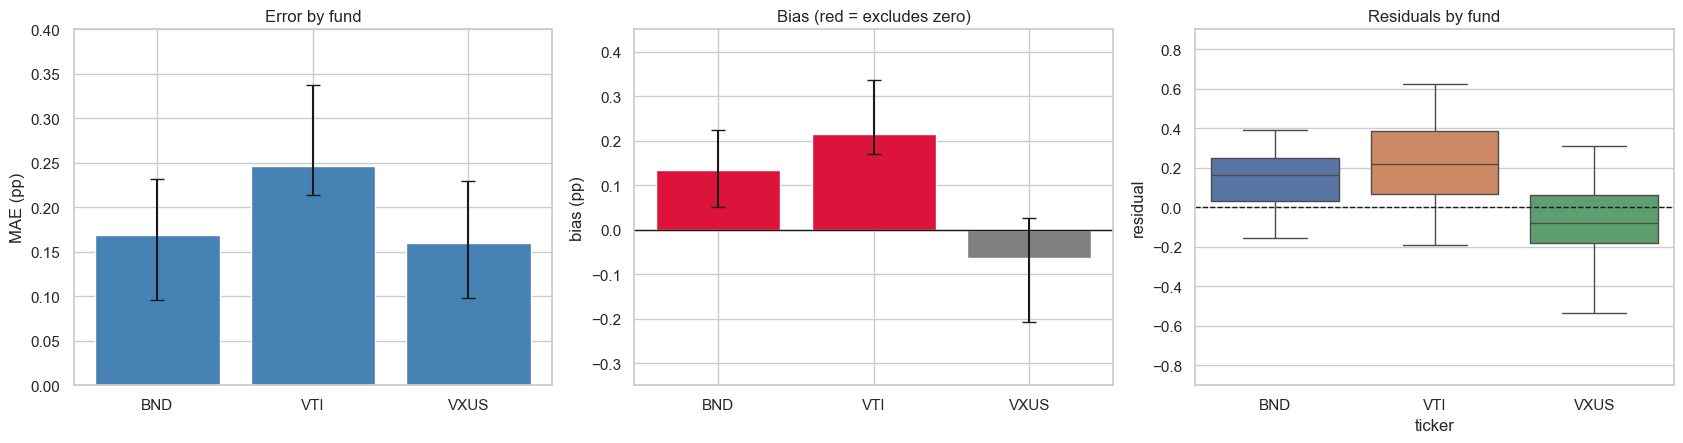

In [9]:
subgroups = ev.subgroup_report(test, resid, group='ticker', block=10,
                               n_boot=N_BOOT, seed=SEED, level=LEVEL)
display(subgroups)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
funds = list(subgroups.index)

axes[0].bar(funds, subgroups['mae'],
            yerr=[subgroups['mae'] - subgroups['mae_lo'],
                  subgroups['mae_hi'] - subgroups['mae']],
            color='steelblue', capsize=5)
axes[0].set_ylim(0, 0.4); axes[0].set_ylabel('MAE (pp)')
axes[0].set_title('Error by fund')

axes[1].bar(funds, subgroups['bias'],
            yerr=[subgroups['bias'] - subgroups['bias_lo'],
                  subgroups['bias_hi'] - subgroups['bias']],
            color=['crimson' if z else 'grey' for z in subgroups['bias_excludes_zero']],
            capsize=5)
axes[1].axhline(0, color='k', linewidth=1)
axes[1].set_ylim(-0.35, 0.45); axes[1].set_ylabel('bias (pp)')
axes[1].set_title('Bias (red = excludes zero)')

sns.boxplot(data=test.assign(residual=resid), x='ticker', y='residual',
            ax=axes[2], hue='ticker', legend=False, order=funds)
axes[2].axhline(0, color='k', linestyle='--', linewidth=1)
axes[2].set_ylim(-0.9, 0.9)
axes[2].set_title('Residuals by fund')

fig.tight_layout()
fig.savefig(IMG / 'eval_subgroups.png', dpi=110, bbox_inches='tight')
plt.show()

**This is the most actionable finding in the stage.**

| Fund | MAE | bias | 95% bias CI | bias share of MAE |
|---|---|---|---|---|
| VTI | 0.246 | **+0.215** | [+0.169, +0.337] | **87%** |
| BND | 0.169 | **+0.134** | [+0.051, +0.223] | **79%** |
| VXUS | 0.160 | -0.063 | [-0.208, +0.027] | 40% |

**VTI and BND have bias intervals that exclude zero.** The pooled model predicts them too
low, systematically, and for VTI 87% of the total error is that fixed offset rather than
noise. More data will not fix it: it is the pooled-coefficient damage Stage 08 predicted,
arriving where the subgroup check was designed to catch it.

**The pooled model should not be reported per fund without a correction.** Either per-fund
models or per-fund interactions, and the fund dummies already exist.

## 6. What the monitor can now publish

,fund,as_of,point,lo,hi,bias_corrected,amber_in_interval
0,VTI,2026-07-30,0.364,0.035,0.802,0.579,False
1,BND,2026-07-30,1.433,1.103,1.870,1.567,False
2,VXUS,2026-07-30,1.036,0.706,1.473,0.973,False


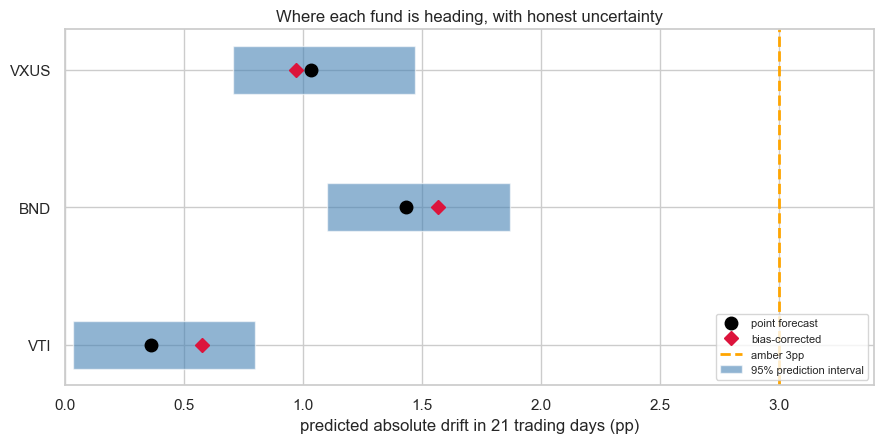

widest upper bound 1.870 pp against an amber line of 3.0 pp


In [10]:
latest = test.sort_values('date').groupby('ticker').tail(1)
point = md.predict_ols(fit['beta'], latest[FULL].to_numpy())

report = ev.prediction_interval(point, resid, level=LEVEL)
report.insert(0, 'fund', latest['ticker'].to_numpy())
report.insert(1, 'as_of', latest['date'].dt.date.to_numpy())
report['bias_corrected'] = report['point'] + report['fund'].map(subgroups['bias'])
report['amber_in_interval'] = report['hi'] >= AMBER_PP
display(report.round(3))

fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(report))
ax.barh(y, report['hi'] - report['lo'], left=report['lo'], height=0.35,
        color='steelblue', alpha=0.6, label='95% prediction interval')
ax.plot(report['point'], y, 'o', color='black', markersize=9, label='point forecast')
ax.plot(report['bias_corrected'], y, 'D', color='crimson', markersize=7,
        label='bias-corrected')
ax.axvline(AMBER_PP, color='orange', linestyle='--', linewidth=2, label='amber 3pp')
ax.set_yticks(y); ax.set_yticklabels(report['fund'])
ax.set_xlim(0, 3.4)
ax.set_xlabel('predicted absolute drift in 21 trading days (pp)')
ax.set_title('Where each fund is heading, with honest uncertainty')
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()
fig.savefig(IMG / 'eval_forecast_intervals.png', dpi=110, bbox_inches='tight')
plt.show()

print('widest upper bound %.3f pp against an amber line of %.1f pp' % (report['hi'].max(), AMBER_PP))

## 7. Save

In [11]:
import datetime as dt
stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')

sweep.to_csv(PROC / f'eval_block_sweep_{stamp}.csv')
comparison.to_csv(PROC / f'eval_intervals_{stamp}.csv')
units.to_csv(PROC / f'eval_unit_scenarios_{stamp}.csv')
subgroups.to_csv(PROC / f'eval_subgroups_{stamp}.csv')
report.to_csv(PROC / f'eval_forecast_{stamp}.csv', index=False)

for p in sorted(PROC.glob(f'eval_*{stamp}*')):
    print('%-46s %7d bytes' % (p.name, p.stat().st_size))
print()
for p in sorted(IMG.glob('eval_*.png')):
    print('%-46s %7d bytes' % (p.name, p.stat().st_size))

eval_block_sweep_20260829-1754.csv                 225 bytes
eval_forecast_20260829-1754.csv                    349 bytes
eval_intervals_20260829-1754.csv                   145 bytes
eval_subgroups_20260829-1754.csv                   270 bytes
eval_unit_scenarios_20260829-1754.csv              212 bytes

eval_block_bootstrap.png                         67533 bytes
eval_forecast_intervals.png                      29022 bytes
eval_intervals.png                               42830 bytes
eval_subgroups.png                               40982 bytes
eval_unit_scenarios.png                          28881 bytes


## 8. Stakeholder summary

**What the monitor forecasts.** In 21 trading days BND is expected to sit **1.43
percentage points** from target, VXUS **1.04**, VTI **0.36**. Allowing for uncertainty the
widest any reaches is **1.87pp**, against an amber threshold of 3pp.

**No fund is expected to need attention within the next month, and that survives the
uncertainty rather than depending on a point estimate.** It is the first forward-looking
statement this project has been able to make with a bound attached.

### Holds if

- volatility stays in the range of the past year, about 13% annualized for VTI and 17%
  for VXUS;
- the equity-over-bond spread driving the drift persists in the same direction;
- prices keep arriving without gaps, which Stage 06 handles and Stage 09 monitors.

### Sensitive to

- **which fund is being asked about.** VTI is systematically 0.21pp low and BND 0.13pp
  low. Apply the correction before quoting a per-fund number.
- **the feature count.** Eleven overfits, five is better, and by more in relative units.
- **the length of the evaluation window**, more than to any modelling choice.

### Not sensitive to

- **the threshold unit.** 25.8% improvement in pp, 25.6% relative. The principal's open
  decision can be made on operational grounds.
- **the normality assumption.** Residuals are slightly thin-tailed, so a Gaussian interval
  is mildly conservative.

### Risks, and what to monitor in production

| Risk | Monitoring |
|---|---|
| Regime change breaks the trend the model relies on | Track realized volatility against the 13% / 17% / 4% band; re-estimate if it moves outside |
| Per-fund bias grows | Track rolling per-fund mean residual; alert if a bias interval moves further from zero |
| The interval is a floor, not a bound | Re-run the block sweep as the window lengthens; the 21-day block becomes usable at roughly 200 test dates |
| Vendor gaps return | `close_was_filled` is already built and currently constant; alert if it stops being |

### Next steps

1. **Do not publish a confidence interval.** Publish the prediction interval.
2. **Correct the per-fund bias** before Stage 12, with per-fund interactions.
3. **Treat every interval here as a floor.**
4. **More history, not a better model**, is what would make this trustworthy.